# **Description** 

####  This project analyzed the occurance, location and prevalence of UFO sightings in 

### the United States in the last century. For further analysis we will also see if there 

### are any correlations with UFO sightings and US general elections.

## Questions to Answer
### Through the analysis of the available data, I will try answering to the following questions:

1. Which is the most common UFO shape seen?
2. Where do most of the UFO sightings happen (in which state)?
3. Which are the states with the most UFO sightings per capita?
4. What is the year with most sightings?
5. In what time of the year (month) do people report seeing more UFOs?

6. I wonder what people say the most when they see an UFO


In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
import warnings
%matplotlib inline
import plotly.express as px

warnings.filterwarnings('ignore')

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


/kaggle/input/ufo-sightings/complete.csv
/kaggle/input/ufo-sightings/scrubbed.csv


# Loading the Data

In [2]:
# Loading the Data
df = pd.read_csv('/kaggle/input/ufo-sightings/complete.csv',low_memory=False,warn_bad_lines=False,error_bad_lines=False)
df.head(5)

,datetime,city,state,country,shape,duration (seconds),duration (hours/min),comments,date posted,latitude,longitude
0,10/10/1949 20:30,san marcos,tx,us,cylinder,2700,45 minutes,This event took place in early fall around 194...,4/27/2004,29.8830556,-97.941111
1,10/10/1949 21:00,lackland afb,tx,NaN,light,7200,1-2 hrs,1949 Lackland AFB&#44 TX. Lights racing acros...,12/16/2005,29.38421,-98.581082
2,10/10/1955 17:00,chester (uk/england),NaN,gb,circle,20,20 seconds,Green/Orange circular disc over Chester&#44 En...,1/21/2008,53.2,-2.916667
3,10/10/1956 21:00,edna,tx,us,circle,20,1/2 hour,My older brother and twin sister were leaving ...,1/17/2004,28.9783333,-96.645833
4,10/10/1960 20:00,kaneohe,hi,us,light,900,15 minutes,AS a Marine 1st Lt. flying an FJ4B fighter/att...,1/22/2004,21.4180556,-157.803611


In [3]:
# Number of Rows and columns 
rows_col = df.shape
print("Total number of Rows in the dataset : {}".format(rows_col[0]))
print("Total number of columns in the dataset : {}".format(rows_col[1]))

Total number of Rows in the dataset : 88679
Total number of columns in the dataset : 11


In [4]:
#  delete duplicated row
df.drop_duplicates()

,datetime,city,state,country,shape,duration (seconds),duration (hours/min),comments,date posted,latitude,longitude
0,10/10/1949 20:30,san marcos,tx,us,cylinder,2700,45 minutes,This event took place in early fall around 194...,4/27/2004,29.8830556,-97.941111
1,10/10/1949 21:00,lackland afb,tx,NaN,light,7200,1-2 hrs,1949 Lackland AFB&#44 TX. Lights racing acros...,12/16/2005,29.38421,-98.581082
2,10/10/1955 17:00,chester (uk/england),NaN,gb,circle,20,20 seconds,Green/Orange circular disc over Chester&#44 En...,1/21/2008,53.2,-2.916667
3,10/10/1956 21:00,edna,tx,us,circle,20,1/2 hour,My older brother and twin sister were leaving ...,1/17/2004,28.9783333,-96.645833
4,10/10/1960 20:00,kaneohe,hi,us,light,900,15 minutes,AS a Marine 1st Lt. flying an FJ4B fighter/att...,1/22/2004,21.4180556,-157.803611
...,...,...,...,...,...,...,...,...,...,...,...
88674,9/9/2013 22:00,napa,ca,us,other,1200,hour,Napa UFO&#44,9/30/2013,38.2972222,-122.284444
88675,9/9/2013 22:20,vienna,va,us,circle,5,5 seconds,Saw a five gold lit cicular craft moving fastl...,9/30/2013,38.9011111,-77.265556
88676,9/9/2013 23:00,edmond,ok,us,cigar,1020,17 minutes,2 witnesses 2 miles apart&#44 Red &amp; White...,9/30/2013,35.6527778,-97.477778
88677,9/9/2013 23:00,starr,sc,us,diamond,0,2 nights,On September ninth my wife and i noticed stran...,9/30/2013,34.3769444,-82.695833


In [5]:
# Statistical information
df.describe()

,longitude
count,88679.000000
mean,-85.021836
std,41.421744
min,-176.658056
25%,-112.073333
50%,-87.650000
75%,-77.769738
max,178.441900


In [6]:
#Data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88679 entries, 0 to 88678
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   datetime              88679 non-null  object 
 1   city                  88679 non-null  object 
 2   state                 81270 non-null  object 
 3   country               76314 non-null  object 
 4   shape                 85757 non-null  object 
 5   duration (seconds)    88677 non-null  object 
 6   duration (hours/min)  85660 non-null  object 
 7   comments              88644 non-null  object 
 8   date posted           88679 non-null  object 
 9   latitude              88679 non-null  object 
 10  longitude             88679 non-null  float64
dtypes: float64(1), object(10)
memory usage: 7.4+ MB


In [7]:
#Date
df["datetime"] = df["datetime"].apply(lambda x: x.replace("24:00", "00:00"))
df['datetime'] = pd.to_datetime(df['datetime'])

In [8]:
#Seconds datastype to numeric
df['duration (seconds)'] = pd.to_numeric(df['duration (seconds)'],errors='coerce')

In [9]:
#creating year seperate columns
df['year']=df['datetime'].dt.year

In [10]:
# number of Null 
df.isnull().sum()

datetime                    0
city                        0
state                    7409
country                 12365
shape                    2922
duration (seconds)          5
duration (hours/min)     3019
comments                   35
date posted                 0
latitude                    0
longitude                   0
year                        0
dtype: int64

In [11]:
def missing (df):
    missing_number = df.isnull().sum().sort_values(ascending=False)
    missing_percent = (df.isnull().sum()/df.isnull().count()).sort_values(ascending=False)*100
    missing_percent = round(missing_percent,2)
    missing_values = pd.concat([missing_number, missing_percent], axis=1, keys=['Missing_Number', 'Missing_Percent'])
    return missing_values

In [12]:
(df.isnull().sum()/df.isnull().count()).sort_values(ascending=False)*100

country                 13.943549
state                    8.354853
duration (hours/min)     3.404414
shape                    3.295030
comments                 0.039468
duration (seconds)       0.005638
datetime                 0.000000
city                     0.000000
date posted              0.000000
latitude                 0.000000
longitude                0.000000
year                     0.000000
dtype: float64

In [13]:
missing(df)

,Missing_Number,Missing_Percent
country,12365,13.94
state,7409,8.35
duration (hours/min),3019,3.40
shape,2922,3.30
comments,35,0.04
duration (seconds),5,0.01
datetime,0,0.00
city,0,0.00
date posted,0,0.00
latitude,0,0.00


# Which is the most common UFO shape seen?

In [14]:
df['shape'].unique()

array(['cylinder', 'light', 'circle', 'sphere', 'disk', 'fireball',
       'unknown', 'oval', 'other', 'cigar', 'rectangle', 'chevron',
       'triangle', 'formation', nan, 'delta', 'changing', 'egg', 'flash',
       'diamond', 'cross', 'teardrop', 'cone', 'pyramid', 'round',
       'crescent', 'flare', 'hexagon', 'dome', 'changed'], dtype=object)

In [15]:
# Change column name to unify both unknown and other shapes
df['shape'] = df['shape'].str.replace('Other', 'Other/Unknown')

In [16]:
# Frequency table
pd.crosstab(index=df['shape'], columns='count').sort_values('count', ascending=False)

col_0,count
shape,
light,17872
triangle,8489
circle,8453
fireball,6562
unknown,6319
other,6247
disk,6005
sphere,5755
oval,4119


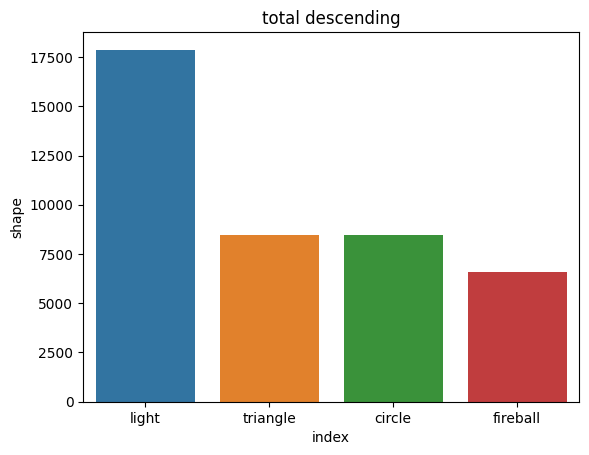

In [17]:
appear = pd.DataFrame(df['shape'].value_counts().head(4)).reset_index()
ax = sns.barplot(x="index", y="shape", data=appear).set(title='total descending')

## Answer
Most respondents report seeing a light, which isn't an actual shape.

Moreover 6,319 sightings don't have a clearly defined shape, or this is unknown for the respondent, so we will exclude this segment for this analysis.

Having said that, the 5 most common identified shapes are:

* light (17,872)
* triangle (8,489)
* circle (8,453) 
* fireball (6,562) 

# Where do most of the UFO sightings happen (in which state)?

In [18]:
# Frequency table
freq = pd.crosstab(index=df['state'], columns='count').sort_values('count', ascending=False)
freq.head(10)

col_0,count
state,
ca,10449
wa,4650
fl,4596
tx,4041
ny,3506
az,2938
il,2874
pa,2780
oh,2638


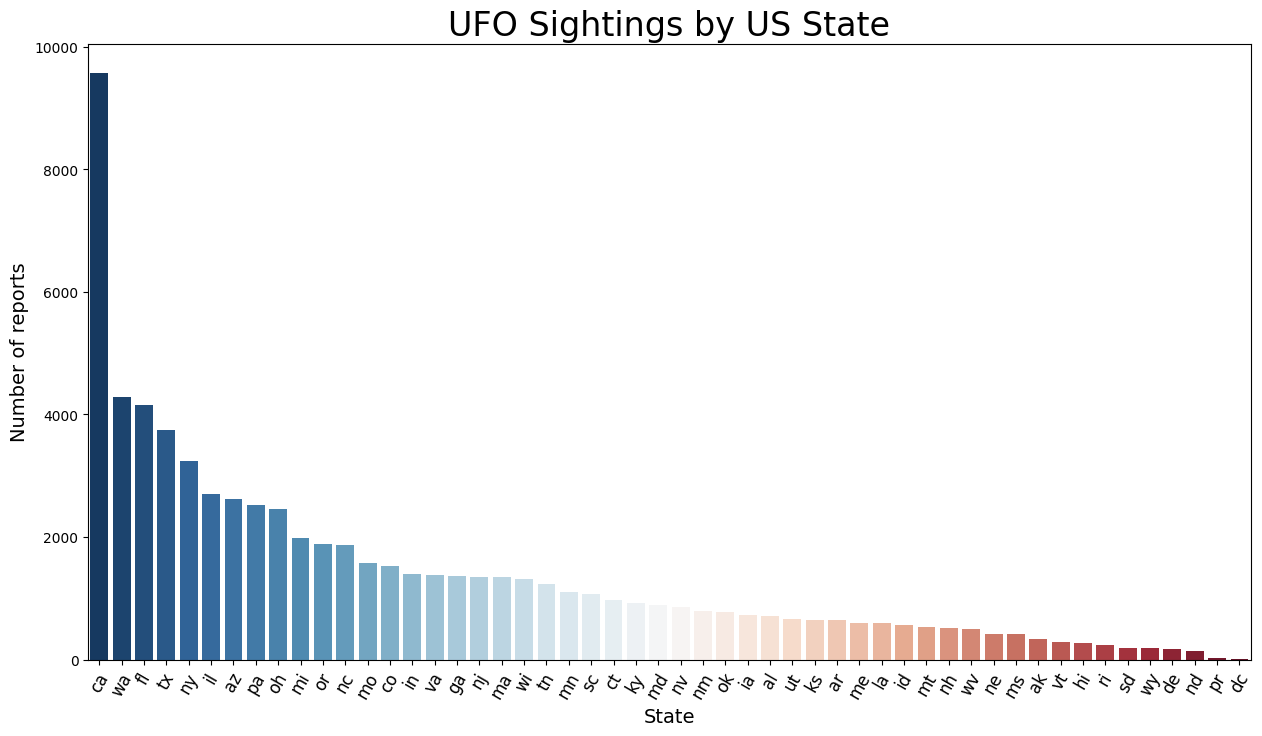

In [19]:
usa_stats = (df['country']=='us')
usdf = df[usa_stats]

state_stats = usdf.state.value_counts()
state_index = state_stats.index 
state_values = state_stats.values
plt.figure(figsize=(15,8))
plt.title('UFO Sightings by US State', fontsize=24)
plt.xlabel("State", fontsize=14)
plt.ylabel("Number of reports", fontsize=14)
plt.xticks(rotation = 60, size=12)
state_plot = sns.barplot(x=state_index[:60],y=state_values[:60], palette='RdBu_r')

Answer
The top 5 for the highest absolute number of UFO sightings is the following:

1. California (10,449)
2. Washington (4,650)
3. Florida  (4,596)
4. Texas (4,041)
5. New York (3,506)

# What is the year with most sightings?

In [20]:
# Frequency table
pd.crosstab(index=df['year'], columns='count').sort_values('count', ascending=False).head(10)

col_0,count
year,
2012,7925
2013,7598
2011,5521
2008,5226
2009,4932
2004,4700
2010,4690
2007,4673
2005,4465


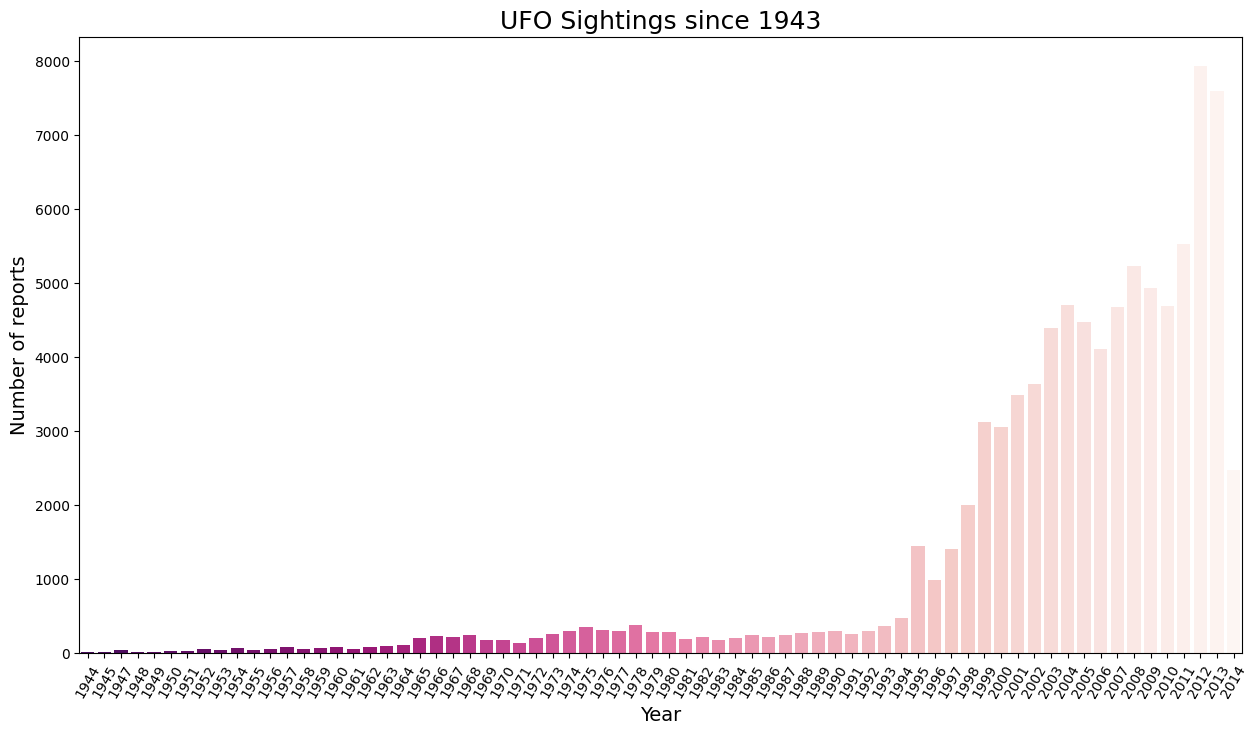

In [21]:
years_data = df['year'].value_counts()
years_index = years_data.index  
years_values = years_data.values
plt.figure(figsize=(15,8))
plt.xticks(rotation = 60)
plt.title('UFO Sightings since 1943', fontsize=18)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Number of reports", fontsize=14)
years_plot = sns.barplot(x=years_index[:70],y=years_values[:70], palette = "RdPu_r")

## Answer
### Most sightings happened during the year 2014.

Here are the years with the highest number of UFO sightings:

* 2012 (7,925)
* 2013 (7,598)
* 2011 (5,521)
* 2008 (5,226)
* 2009 (4,932)


# In what time of the year (month) do people report seeing more UFOs?

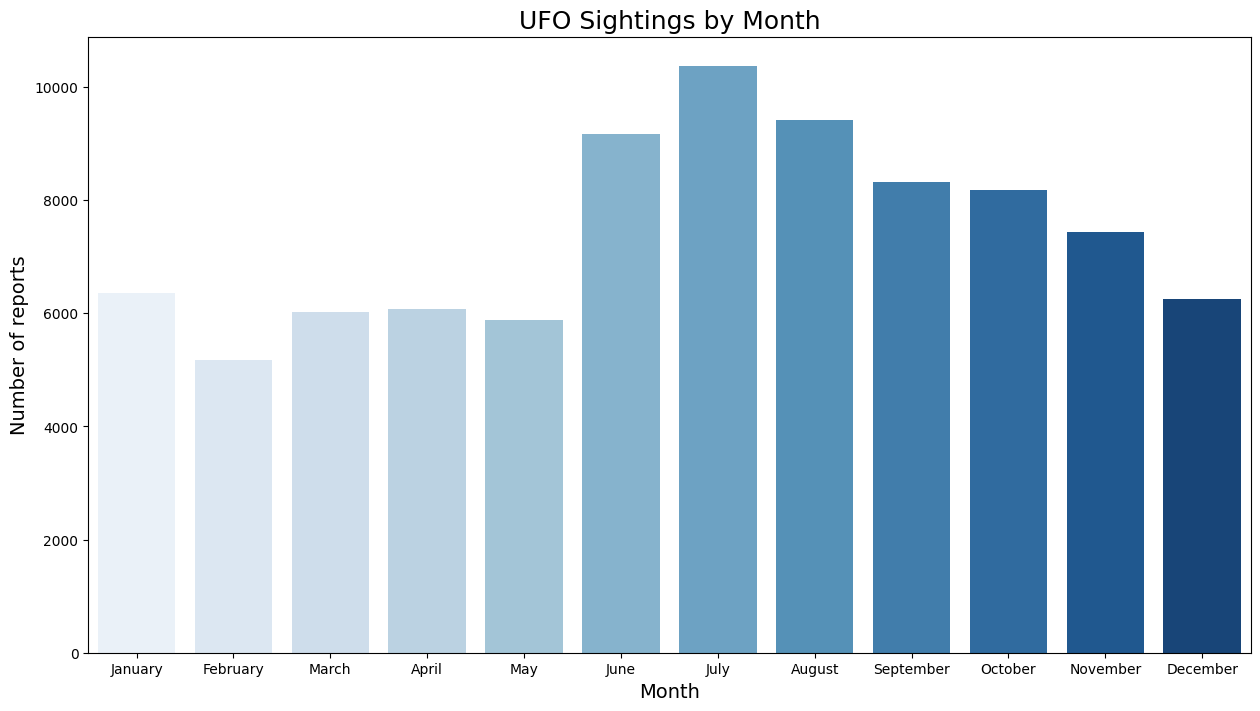

In [22]:
order = ["January", "February", "March", "April", "May", "June", "July","August", "September", 
         "October", "November", "December"]
df['month'] = df['datetime'].dt.month_name() #turns month numbers into month names
month_data = df['month'].value_counts() 
month_index = month_data.index 
month_values = month_data.values
plt.figure(figsize=(15,8))
plt.title('UFO Sightings by Month', fontsize=18)
plt.xlabel("Month",fontsize=14)
plt.ylabel("Number of reports", fontsize=14)
month_plot = sns.barplot(x=month_index[:60],y=month_values[:60], palette = "Blues", order=order)

## Answer
### Most of the UFO sightings reported happen during the following months:

1. July
2. August
3. June
4. September
5. October
Is it interesting to note that the months with most sightings happen to be during the summer, aka the hottest months of the year. It is a period in which people tend to spend more time outdoors. Which can influence the result as people will more likely have opportunity to skygaze and, consequently, see more UFO-like objects.

# UFO - Most Visited Place in Earth


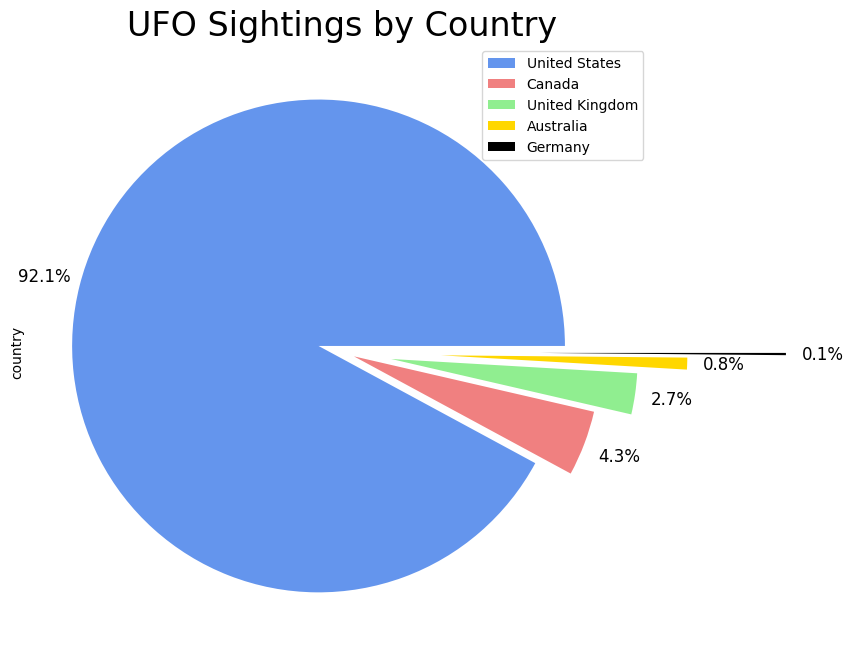

In [23]:
#UFO - Most Visited Place
plt.subplots(figsize=(18,8))
expl = (0.1,0.05,0.2,0.4,0.8)
colors = ["cornflowerblue", "lightcoral", "lightgreen", "gold", "black"]
labels =['United States', 'Canada', 'United Kingdom', 'Australia', 'Germany']

df['country'].value_counts().plot(kind='pie',fontsize = 12, colors=colors, 
                                  explode=expl, figsize = (8,8), autopct='%.1f%%', 
                    pctdistance=1.15, labels=None)
plt.legend(labels=labels, loc='upper right')
plt.title('UFO Sightings by Country', size=24)

plt.xticks(rotation=45, fontsize=15)
plt.show()

## UFO - count of visits over years


Text(0, 0.5, 'Count')

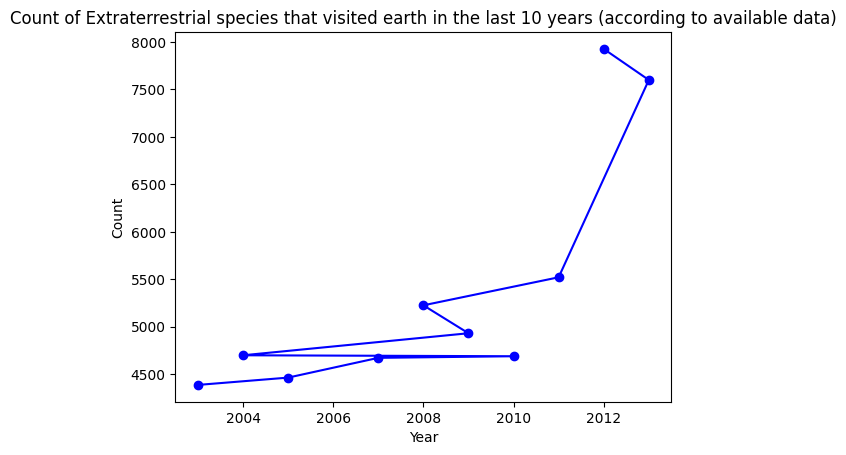

In [24]:
#UFO - count of visits over years
yr_plot = pd.DataFrame(df['year'].value_counts().head(10)).reset_index()
plt.plot(yr_plot['index'], yr_plot['year'], marker='o', color='b')
plt.title('Count of Extraterrestrial species that visited earth in the last 10 years (according to available data)')
plt.xlabel('Year')
plt.ylabel('Count')

# UFO - Average time period stayed in earth in top 10 years


Text(0.5, 1.0, 'Extraterrestial species VISA average time period to stay on earth between years')

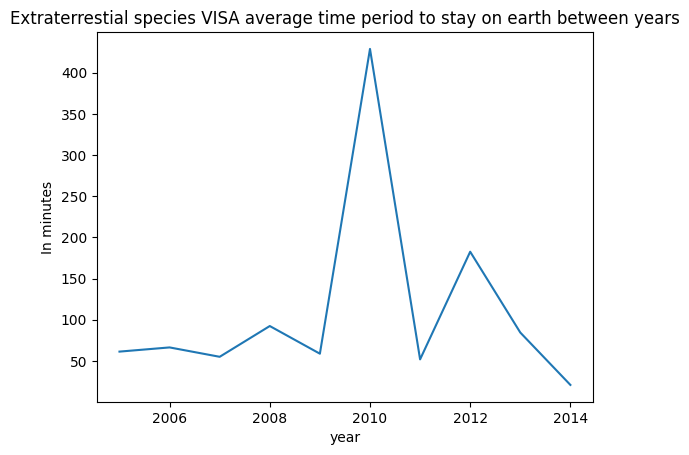

In [25]:
#UFO - Average time period stayed in earth in top 10 years
time_stay = df[['year','duration (seconds)']][df['duration (seconds)'] >= 20]
time_stay_sec = pd.DataFrame(time_stay.groupby('year')['duration (seconds)'].mean().tail(10))
time_stay_min = time_stay_sec['duration (seconds)']/60
plt.plot(time_stay_min)
plt.ylabel('In minutes')
plt.xlabel('year')
plt.title('Extraterrestial species VISA average time period to stay on earth between years')


# I wonder what people say the most when they see an UFO

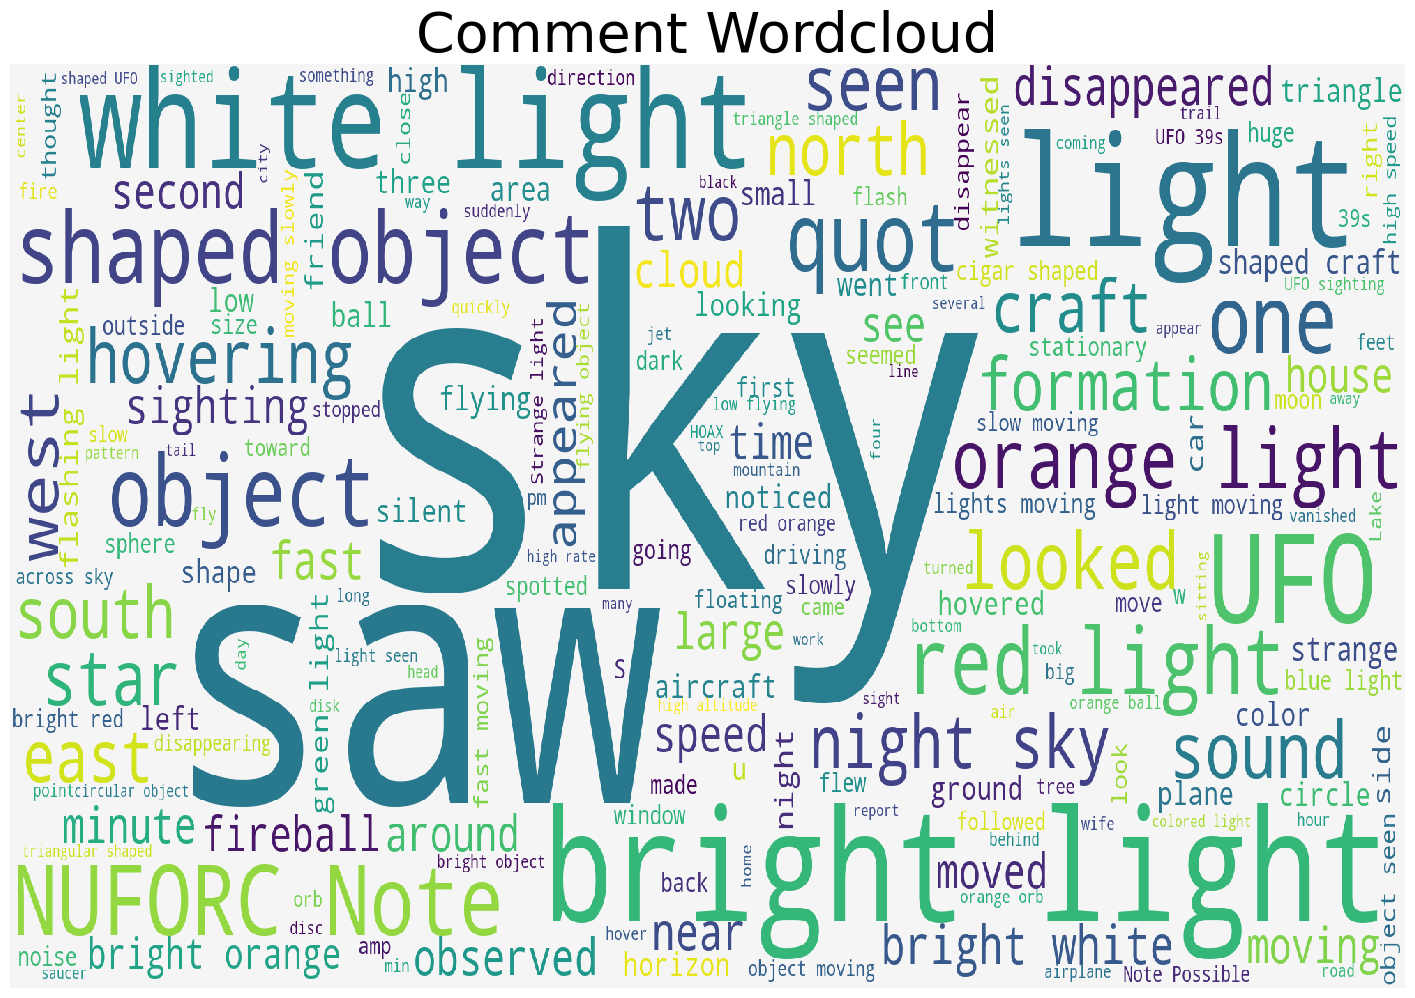

In [26]:
cmt = [item for item in df.comments.dropna()]
    
cmt = " ".join(cmt)

plt.figure(figsize=(18,12))

wordcloud = WordCloud(background_color='whitesmoke', width=2000, height=1000,
                      stopwords=None).generate(cmt)
plt.imshow(wordcloud, interpolation="nearest", aspect='auto')
plt.axis('off')
plt.savefig('wordcloud.png')
plt.title("Comment Wordcloud", size=40)

plt.show()